# Projeto Semantix: Manutenção Preditiva Industrial (Industry 4.0)

Este notebook documenta o desenvolvimento de um modelo de Machine Learning voltado para a **Manutenção Preditiva** de maquinários industriais. O objetivo principal é utilizar dados de sensores para prever falhas em equipamentos antes que elas ocorram, otimizando paradas técnicas e reduzindo custos operacionais.

## 1. O Problema de Negócio (Problemática)

Na indústria moderna (Indústria 4.0), a quebra inesperada de um maquinário na linha de produção gera consequências severas:
* **Prejuízos Financeiros:** Tempo de inatividade não planejado (*downtime*) pode custar milhares de dólares por hora.
* **Desperdício de Recursos:** A manutenção corretiva (esperar quebrar para consertar) costuma ser muito mais cara do que a preventiva.
* **Riscos de Segurança:** Falhas catastróficas em equipamentos de alta pressão, temperatura ou rotação colocam a integridade dos operadores em risco.

### A Abordagem Preditiva
Tradicionalmente, indústrias utilizam manutenções preventivas baseadas em tempo de uso (ex: trocar uma peça a cada 6 meses). No entanto, isso muitas vezes resulta na troca prematura de componentes ainda saudáveis. 

A **Manutenção Preditiva** utiliza algoritmos de Machine Learning alimentados por dados de sensores em tempo real para estimar o momento exato em que uma máquina começará a falhar. 


## 2. A Relevância do Uso de Dados

Por que a análise de dados e o Machine Learning são indispensáveis para resolver este problema?

### A complexidade física dos equipamentos
O desgaste de uma máquina ferramenta não é um processo puramente linear ou baseado apenas no tempo. Ele é o resultado de uma **interação dinâmica e complexa** entre múltiplas variáveis físicas:
* A velocidade de rotação altera a vibração e o atrito.
* O torque aplicado gera estresse mecânico direto nos materiais.
* A temperatura do processo acelera o desgaste térmico e a fadiga dos componentes.

### O papel do Machine Learning
Tentar modelar essa interação usando regras de decisão manuais ("se a temperatura passar de X e a velocidade for Y, então pare") é ineficiente e impreciso, pois as falhas costumam dar sinais sutis através de padrões multidimensionais que o olho humano não consegue correlacionar em tempo real.

O uso de dados e algoritmos de Machine Learning permite:
1. **Identificação de Padrões Multidimensionais:** O modelo analisa simultaneamente a temperatura, o torque, a velocidade e o desgaste acumulado para encontrar a assinatura exata que precede uma falha.
2. **Manutenção Baseada na Condição Real:** Em vez de seguir um calendário rígido, a equipe de manutenção age com base no estado real de saúde de cada máquina individualmente (Manutenção Baseada em Condição - CbM).
3. **Redução do Erro Humano e Alertas Automatizados:** O pipeline de dados analisa o fluxo de sensores continuamente, eliminando a necessidade de inspeções visuais manuais constantes e demoradas.

Em suma, **os dados transformam a manutenção de um centro de custos reativo em uma vantagem competitiva preditiva**, gerando economia financeira massiva e garantindo a segurança do ecossistema fabril.

## 3. O Dataset e Fonte dos Dados

Para este projeto, utilizaremos o **AI4I 2020 Predictive Maintenance Dataset**, disponibilizado pelo repositório de Machine Learning da **UCI (University of California, Irvine)**.

* **Link Oficial para Download:** [UCI Machine Learning Repository - AI4I 2020 Predictive Maintenance Dataset](https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset)
* **Tamanho do Dataset:** 10.000 instâncias (linhas) e 14 colunas (variáveis).

### Variáveis do Dataset (Dicionário de Dados)

O dataset simula de forma extremamente realista as condições de operação de fresadoras industriais (CNC) e possui os seguintes atributos:

| Variável | Tipo | Descrição |
| :--- | :--- | :--- |
| **UID** | Integer | Identificador único do registro (1 a 10.000). |
| **Product ID** | Categórico | Identificador do produto que indica a qualidade: **L** (Low - 50%), **M** (Medium - 30%) ou **H** (High - 20%), seguido de um número de série. |
| **Type** | Categórico | Identificador do produto que indica a qualidade: **L** (Low - 50%), **M** (Medium - 30%) ou **H** (High - 20%). |
| **Air temperature [K]** | Continuous | Temperatura do ar ambiente em Kelvin (gerada por processo de random walk em torno de 300 K). |
| **Process temperature [K]** | Continuous | Temperatura do processo de usinagem em Kelvin (gerada adicionando 10 K à temperatura do ar). |
| **Rotational speed [rpm]** | Integer | Velocidade de rotação do eixo da máquina (calculada a partir de uma potência de 2860 W com ruído). |
| **Torque [Nm]** | Continuous | Torque aplicado na ferramenta em Newton-metros. |
| **Tool wear [min]** | Integer | Desgaste acumulado da ferramenta de corte em minutos. |
| **Machine Failure** | Binário (*Target*) | Variável alvo: indica se a máquina falhou (**1**) ou não (**0**). |

Além disso, o dataset contém 5 variáveis binárias detalhando o tipo exato da falha ocorrida (para tarefas de classificação multi-classe ou análise aprofundada):
1. **TWF** (Tool Wear Failure): Falha por desgaste excessivo da ferramenta.
2. **HDF** (Heat Dissipation Failure): Falha por dissipação inadequada de calor.
3. **PWF** (Power Failure): Falha por falta ou pico de energia.
4. **OSF** (Overstrain Failure): Falha por sobrecarga/esforço excessivo da máquina.
5. **RNF** (Random Failure): Falhas de origem aleatória (não ligadas diretamente aos parâmetros de processo).


In [1]:
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização de dados
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# Bibliotecas para pré-processamento e divisão de dados
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline 
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

# Bibliotecas para os modelos de machine learning
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Bibliotecas para métricas de avaliação
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, confusion_matrix

## Importação dos dados

In [2]:
# Carregando o dataset
df = pd.read_csv('ai4i2020.csv')

In [3]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [4]:
# Verificar tipos de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [5]:
# Verificar nulos
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Foi feita a verificação de valores nulos, mesmo que na fonte dos dados indicasse a ausência de nulos, como uma verificação de segurança

In [6]:
# Removendo identificadores irrelevantes para o modelo
df = df.drop(columns=['UDI', 'Product ID'])

Removeu-se 'UDI' e 'Product ID' porque são apenas identificadores, não possuem correlação física com o comportamento operacional dos sensores. 

## Análise Exploratória dos dados (EDA)

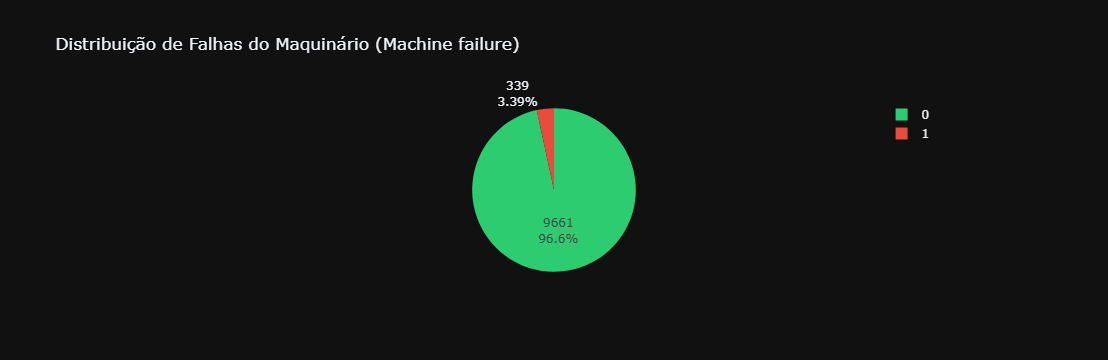

In [7]:
# Criando o gráfico de pizza interativo para mapear a distribuição da classe alvo
fig_target = px.pie(
    df, 
    names='Machine failure', 
    title='Distribuição de Falhas do Maquinário (Machine failure)',
    color='Machine failure',
    color_discrete_map={0: '#2ecc71', 1: '#e74c3c'}, # Verde para normal, Vermelho para falha
    template='plotly_dark'
)
fig_target.update_traces(textinfo='percent+value', pull=[0, 0.1])
fig_target.show()

O gráfico nos mostra um desbalanceamento Extremo de Classes:

 - Classe 0 (Sem Falha / Normal): 9.661 ocorrências (96,6%).
 - Classe 1 (Falha / Machine Failure): 339 ocorrências (3,39%).

Isso impacta diretamente no modelo, explicitando a necessidade de balanceamento na etapa de pré-processamento.

In [8]:
# Isolando as falhas específicas e somando suas ocorrências
colunas_falhas = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
soma_falhas = df[colunas_falhas].sum().reset_index()
soma_falhas.columns = ['Tipo de Falha', 'Ocorrências']

# Plotando gráfico de barras ordenado para identificar os maiores problemas na fábrica
fig_falhas = px.bar(
    soma_falhas.sort_values(by='Ocorrências', ascending=False),
    x='Tipo de Falha',
    y='Ocorrências',
    title='Frequência das Causas Raiz de Falhas na Fábrica',
    labels={'Ocorrências': 'Número de Casos'},
    color='Ocorrências',
    color_continuous_scale='Reds',
    template='plotly_dark'
)
fig_falhas.show()

O gráfico de barras identifica a distribuição das falhas por tipo específico, permitindo isolar os gargalos críticos da operação:

 -  Predominância de Três Causas Principais: As falhas do tipo **HDF** (Heat Dissipation Failure), **OSF** (Overstrain Failure) e **PWF** (Power Failure) são os problemas mais frequentes na fábrica, operando em patamares muito próximos (entre ~90 e ~115 casos cada).
 -  Falhas Secundárias: Os eventos de **TWF** (Tool Wear Failure) e **RNF** (Random Failures) apresentam volume significativamente menor, com RNF sendo o evento mais raro registrado.

Gargalos Operacionais & Engenharia de Recursos:
1. Foco de Atuação (Lei de Pareto): Esforços de manutenção preventiva e melhorias de engenharia devem ser priorizados estritamente nos três primeiros pilares (HDF, OSF, PWF), pois eles combinados representam a vasta maioria das paradas de máquina.
2. Direcionamento de Negócio: 
   - **HDF:** Sugere a necessidade de revisão nos sistemas de arrefecimento ou dissipação térmica das máquinas.
   - **OSF:** Indica componentes operando sob fadiga ou acima do limite nominal de esforço físico.
   - **PWF:** Aponta para instabilidades ou picos no fornecimento de energia elétrica do circuito.


In [9]:
# Definindo as variáveis numéricas de sensores que queremos analisar
sensores = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

# Loop para gerar um boxplot dinâmico para cada sensor baseado no estado de falha
for sensor in sensores:
    fig_box = px.box(
        df,
        x='Machine failure',
        y=sensor,
        color='Machine failure',
        color_discrete_map={0: '#2ecc71', 1: '#e74c3c'},
        title=f'Distribuição de {sensor} por Estado de Falha (Machine failure)',
        points='outliers', # Mostra os outliers individualmente nas extremidades
        template='plotly_dark'
        )
    fig_box.show()

Temperatura (Air temperature & Process temperature)
* Ambos os gráficos mostram uma clara tendência de elevação térmica quando ocorre a falha (Classe 1). A mediana da temperatura do ar e do processo é visivelmente mais alta nos casos de falha.
*  O superaquecimento (provavelmente relacionado à falha do tipo *HDF - Heat Dissipation Failure* mapeada anteriormente) é um forte indicador de quebra iminente.

Velocidade de Rotação (Rotational speed)
* A distribuição da classe normal (Classe 0) se concentra fortemente ao redor de 1500 rpm. Quando ocorre a falha (Classe 1), a velocidade mediana cai levemente, mas há uma cauda extremamente longa de **outliers de alta velocidade** (atingindo até quase 3000 rpm).
* Picos ou descontroles abruptos de rotação para cima estão intimamente correlacionados com falhas no maquinário.

Torque (Torque)
* Há um deslocamento notável para cima no torque mediano quando ocorre falha. Enquanto a operação normal foca em torno de 40 Nm, as situações de falha têm mediana acima de 50 Nm, estendendo-se até o limite superior próximo de 80 Nm.
* O esforço excessivo/sobrecarga física (torque muito elevado) é um dos principais precursores de falha, o que valida fisicamente a ocorrência das falhas de esforço (*OSF - Overstrain Failure*).

Desgaste da Ferramenta (Tool wear)
* Há uma diferença expressiva entre as medianas dos dois estados. Enquanto as máquinas que operam normalmente apresentam uma mediana de desgaste de 107 min, as máquinas que falharam apresentam uma mediana de desgaste substancialmente maior.
* O desgaste acumulado da ferramenta é um forte fator de risco individual. Máquinas com tempo de operação da ferramenta superior a 150-160 minutos entram em uma zona crítica onde a probabilidade de falha (especialmente por fadiga ou quebra de ferramenta, como *TWF - Tool Wear Failure*) aumenta consideravelmente.


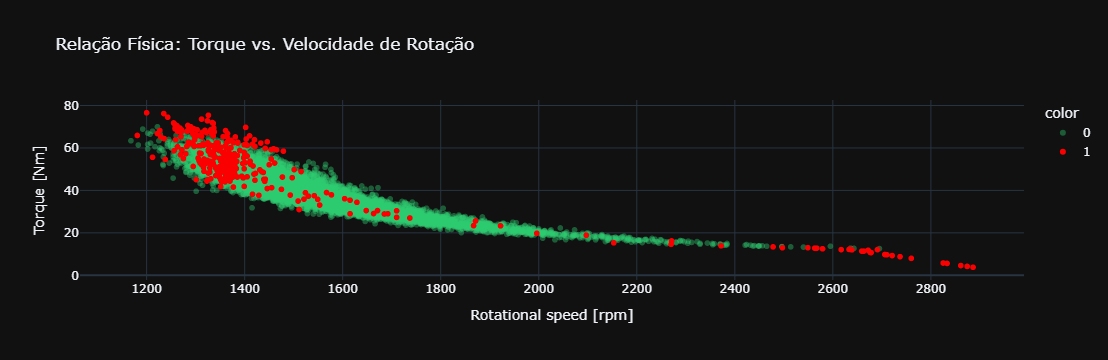

In [10]:
# Plotando a relação física entre Torque e Rotação
fig_scatter = px.scatter(
    df,
    x='Rotational speed [rpm]',
    y='Torque [Nm]',
    color=df['Machine failure'].astype(str),
    color_discrete_map={'0': 'rgba(46, 204, 113, 0.4)', '1': '#fa0000'}, # Transparência no normal para destacar a falha
    title='Relação Física: Torque vs. Velocidade de Rotação',
    template='plotly_dark'
)
fig_scatter.show()

O gráfico revela que as falhas não são aleatórias, mas sim concentradas em fronteiras físicas operacionais:

* Zona de Operação Normal (Verde): Concentra-se no "ventre" da curva, entre 1400 e 2000 rpm com torque de 20 a 50 Nm. É onde a máquina opera de forma saudável. Possuindo pontos de falha possivelmente causados por outros fatores.

* Zona de Sobrecarga (Vermelho - Superior Esquerdo): Baixa rotação (< 1500 rpm) e alto torque (50 a 80 Nm). Indica esforço excessivo do motor, diretamente associado a falhas por sobrecarga física (OSF).

* Zona de Operação em Vazio ou Sobrerrotação (Vermelho - Inferior Direito): Altíssima rotação (> 2400 rpm) com torque extremamente baixo (< 15 Nm). Fisicamente, isso indica que a máquina pode ter perdido o contato de corte com a peça de trabalho (operação em vazio) ou entrou em uma condição de sobrevelocidade fora dos limites operacionais seguros. Isso frequentemente dispara falhas de alimentação/energia (**PWF**) ou paradas de emergência do sistema para evitar danos catastróficos ao motor.


A criação de uma nova variável de Potência multiplicando Torque [Nm] * Rotational speed [rpm] * 2π/60, pode ajudar o modelo a separar facilmente o comportamento anômalo da operação ideal.

In [11]:
# Potência [W] = Torque [Nm] * Rotação [rpm] * (2 * π / 60)
df['Power [W]'] = df['Rotational speed [rpm]'] * df['Torque [Nm]'] * (2 * np.pi / 60)

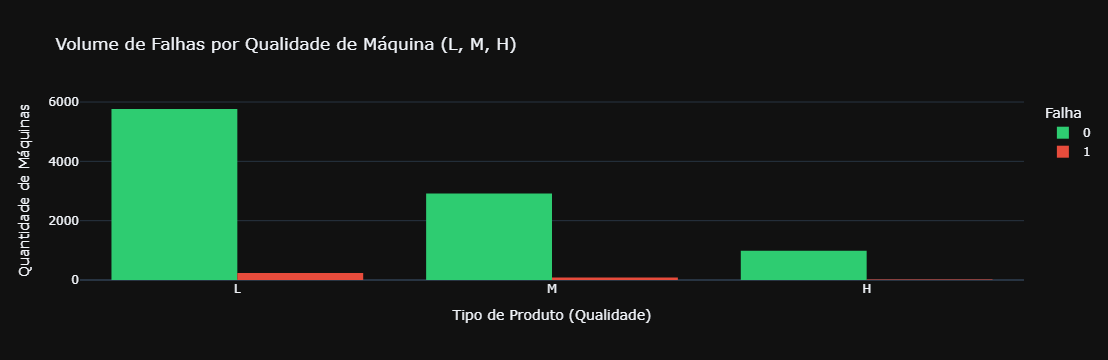

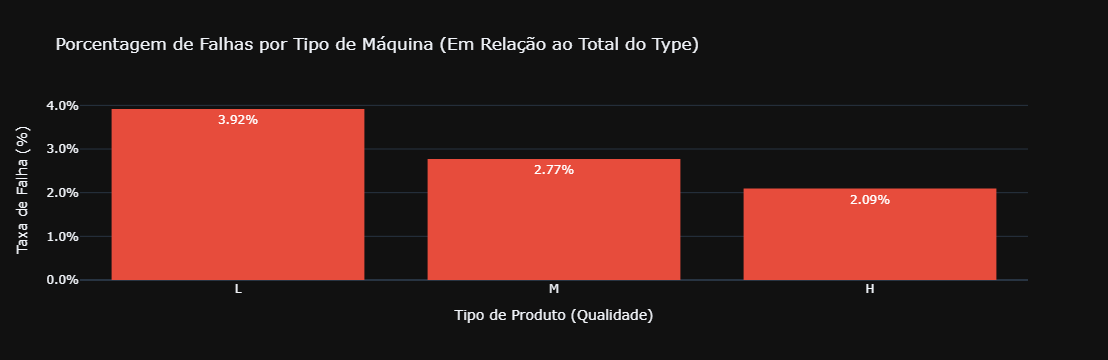

In [12]:
# Volume Absoluto de Falhas
fig1 = px.histogram(
    df,
    x='Type',
    color='Machine failure',
    barmode='group',
    title='Volume de Falhas por Qualidade de Máquina (L, M, H)',
    labels={'Type': 'Tipo de Produto (Qualidade)', 'count': 'Quantidade de Máquinas', 'Machine failure': 'Falha'},
    color_discrete_map={0: '#2ecc71', 1: '#e74c3c'},
    category_orders={'Type': ['L', 'M', 'H']},
    template='plotly_dark'
)

fig1.update_layout(hovermode='x unified', yaxis_title='Quantidade de Máquinas')
fig1.show()


# Taxa Percentual de Falhas por Categoria

fig2 = px.histogram(
    df,
    x='Type',
    y='Machine failure',
    histfunc='avg',  # Calcula a média (proporção de 1s) para cada Type
    text_auto='.2%', # Mostra o texto em porcentagem nas barras
    title='Porcentagem de Falhas por Tipo de Máquina (Em Relação ao Total do Type)',
    labels={'Type': 'Tipo de Produto (Qualidade)', 'Machine failure': 'Taxa de Falha'},
    category_orders={'Type': ['L', 'M', 'H']},
    template='plotly_dark'
)

fig2.update_traces(
    textposition='inside',
    marker_color='#e74c3c' # Mantém o padrão vermelho para indicar quebra
)

fig2.update_layout(
    yaxis_tickformat='.1%',
    yaxis_title='Taxa de Falha (%)'
)
fig2.show()

Os gráficos revelam que o volume absoluto mascara o risco real e que a categoria do produto afeta diretamente a propensão a falhas:

 - Efeito de Escala (Volume): O tipo L concentra a maior quantidade absoluta de quebras simplesmente por possuir a maior base de registros na fábrica (~6.000). Olhar apenas para o volume gera uma falsa impressão de que o problema está isolado nessa categoria.

 - Risco Proporcional (Taxa de Falha): A taxa real de quebra do tipo L (3,92%) é quase o dobro da do tipo H (2,09%). Isso prova que quanto menor a especificação de qualidade do produto processado, maior é a probabilidade da máquina falhar.

Portanto, priorizar a produção ou otimizar o processo dos itens de categoria L pode reduzir drasticamente o número total de paradas. Contudo, qualquer mudança na linha de produção ou migração de portfólio exige um estudo de viabilidade financeira, pesando o valor de mercado de cada tipo de produto contra o custo gerado pelas falhas.

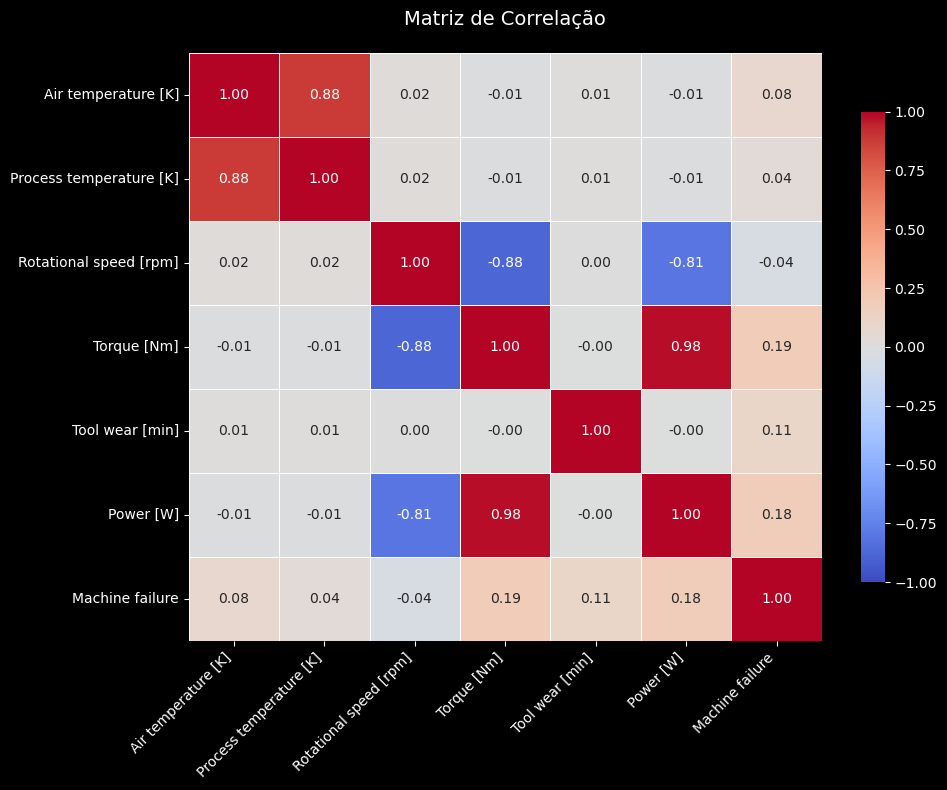

In [13]:
# Matriz correlação
colunas_numericas = [
    'Air temperature [K]', 
    'Process temperature [K]', 
    'Rotational speed [rpm]', 
    'Torque [Nm]', 
    'Tool wear [min]',
    'Power [W]',
    'Machine failure'
]

plt.style.use('dark_background')

df_corr = df[colunas_numericas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_corr, 
    annot=True,
    fmt=".2f", 
    cmap='coolwarm',
    vmax=1, vmin=-1,
    linewidths=0.5, 
    cbar_kws={"shrink": .8}
)

plt.title('Matriz de Correlação', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Os principais pontos observados pela matriz de correlação são:

* Multicolinearidade Crítica (Temperaturas): Air temperature [K] e Process temperature [K] apresentam uma correlação positiva altíssima (0.88). Isto indica redundância linear de dados. Modelos lineares sofrem com esse fenômeno, demandando atenção ou exclusão de uma delas caso o algoritmo escolhido seja sensível à multicolinearidade.
* Relação Inversa da Física Mecânica: Rotational speed [rpm] e Torque [Nm] possuem uma correlação negativa quase perfeita (-0.88). O comportamento reflete a física real do maquinário: o motor entrega torque máximo em baixas rotações e perde força à medida que a velocidade angular atinge limites extremos.
* Comportamento da Feature Criada (Power [W]): A variável de potência calculada exibe altíssima correlação linear com Torque [Nm] (0.98) e forte correlação inversa com Rotational speed [rpm] (-0.81). Ela atua de forma muito redundante em termos estritamente lineares, embora sua utilidade real resida em capturar comportamentos não lineares nas zonas de estresse do motor.
* Relação Não Linear com o Alvo (Machine failure): Nenhum sensor individual exibe forte correlação linear com a falha (a maior delas sendo o Torque com apenas 0.19). Isto comprova que as paradas da máquina não ocorrem pelo aumento linear isolado de uma métrica, mas pela combinação complexa e anômala de eventos simultâneos. Modelos baseados em árvores (como Random Forest e LightGBM) são os mais adequados para este problema.

**Definindo variáveis a manter**

* Type: Deve ser mantida e mapeada. Como visto na análise gráfica anterior, a taxa de falha varia de 2,09% a 3,92% dependendo do tipo de produto, fornecendo um contexto estatístico essencial para o modelo.

* Rotational speed [rpm] e Torque [Nm]: São o coração mecânico do problema. A relação inversa entre elas ajuda o modelo a mapear os extremos operacionais (Zonas de Sobrecarga e Operação em Vazio).

* Power [W] (Variável criada): Vale a pena mantê-la no primeiro teste. Árvores de decisão conseguem extrair regras de corte não lineares eficientes mesmo que a correlação linear pareça redundante.
    * Rpm, Torque e Power (Interação Não Linear) Embora Rotational speed e Torque tenham uma correlação linear fortíssima (-0.88), o comportamento que gera as falhas não é linear. A potência é o produto multiplicativo dessas duas variáveis, e para um modelo de árvore encontrar essa relação multiplicativa sozinho, ele precisaria aumentar a complexidade da árvore. Entregar a Potência pronta dá um "atalho" para o modelo identificar falhas diretamente em uma única quebra de nó, melhorando a eficiência do aprendizado sem causar prejuízo pela correlação. <br><br>
        
* Tool wear [min]: Deve ser mantida. Embora tenha baixa correlação linear com a falha (0.11), o desgaste da ferramenta é um fator cumulativo crucial para falhas do tipo TWF (Tool Wear Failure). 

* Air temperature [K] ou Process temperature [K]: Embora a correlação de 0.88 indique alta redundância linear, o que normalmente justificaria a exclusão de uma das variáveis, o comportamento térmico do maquinário depende de dois fatores independentes: o calor absoluto (que degrada componentes e lubrificantes) e o gradiente térmico (a capacidade do sistema de trocar calor com o ambiente). Para resolver isso, a variável Temp_Difference (Process temperature [K] - Air temperature [K]) será criada (subtraindo a temperatura ambiente da temperatura do processo) para isolar as falhas de dissipação. Em paralelo, manteremos apenas a Process temperature [K] como o termômetro absoluto do sistema. Essa combinação elimina o ruído da multicolinearidade sem causar perda de informação física essencial.


## Tratamento dos dados

In [14]:
# Mapeamento Ordinal Manual da coluna 'Type' (High=2 > Medium=1 > Low=0)
mapeamento_type = {'H': 2, 'M': 1, 'L': 0}

df['Type'] = df['Type'].map(mapeamento_type)

In [15]:
# Renomeando as colunas restantes para simplificar a manipulação (removendo unidades de medida do nome)
novos_nomes = {
    'Air temperature [K]': 'Air_Temperature',
    'Process temperature [K]': 'Process_Temperature',
    'Rotational speed [rpm]': 'Rotational_Speed',
    'Torque [Nm]': 'Torque',
    'Tool wear [min]': 'Tool_Wear',
    'Machine failure': 'Machine_Failure',
    'Power [W]': 'Power'
}
df = df.rename(columns=novos_nomes)

In [16]:
df['Temp_Difference'] = df['Process_Temperature'] - df['Air_Temperature']

In [17]:
# Separando os atributos preditores (X) da variável alvo (y)
X = df.drop(columns=['Machine_Failure'])
y = df['Machine_Failure']

# 2. Dividindo em conjuntos de Treino (80%) e Teste (20%)
# O parâmetro stratify garante que a proporção de falhas seja idêntica em ambos os lados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Dimensões do Treino (X_train): {X_train.shape}")
print(f"Dimensões do Teste (X_test):   {X_test.shape}")
print(f"Dimensões do Treino (y_train): {y_train.shape}")
print(f"Dimensões do Teste (y_test):   {y_test.shape}")

Dimensões do Treino (X_train): (8000, 13)
Dimensões do Teste (X_test):   (2000, 13)
Dimensões do Treino (y_train): (8000,)
Dimensões do Teste (y_test):   (2000,)


In [18]:
# Definindo colunas de falhas específicas observadas na EDA
colunas_para_remover = ['Air_Temperature', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Removendo dos conjuntos de treino e teste
X_train_treated = X_train.drop(columns=colunas_para_remover)
X_test_treated = X_test.drop(columns=colunas_para_remover)

Removemos as colunas de falha para evitar o vazamento de dados (data leakage), pois a presença delas revelaria diretamente o resultado da variável alvo.

In [19]:
print(X_train_treated.columns.tolist())
print(X_test_treated.columns.tolist())

['Type', 'Process_Temperature', 'Rotational_Speed', 'Torque', 'Tool_Wear', 'Power', 'Temp_Difference']
['Type', 'Process_Temperature', 'Rotational_Speed', 'Torque', 'Tool_Wear', 'Power', 'Temp_Difference']


O mapeamento manual garante que o modelo entenda a ordem de grandeza real ($High > Medium > Low$), evitando que o LabelEncoder atribua pesos numéricos incorretos baseados apenas na ordem alfabética.

## Preparar e selecionar Modelo

In [20]:
# Construir Pipeline Random Forest
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),                                             # Normaliza os dados
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100)) # Modelo Random Forest
])

In [21]:
# Construir Pipeline XGBoost
pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),       # Normaliza os dados
    ('smote', SMOTE(random_state=42)),  # Equilibra as classes
    ('xgb', XGBClassifier(              # Modelo XGBoost
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        ))
])

In [22]:
# Definindo as métricas de classificação
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

modelos = [
    ('Random Forest', pipeline_rf),
    ('XGBoost', pipeline_xgb)
]

results_summary = []

print("--- Avaliação Detalhada (Cross-Validation com 5 Folds) ---")

for nome, pipe in modelos:
    # cross_validate executa todas as métricas definidas no dicionário scoring
    cv_results = cross_validate(pipe, X_train_treated, y_train, cv=5, scoring=scoring, n_jobs=-1)
    
    # Armazenando as médias
    results_summary.append({
        'Modelo': nome,
        'Acurácia': np.mean(cv_results['test_accuracy']),
        'Precisão': np.mean(cv_results['test_precision']),
        'Recall': np.mean(cv_results['test_recall']),
        'F1-Score': np.mean(cv_results['test_f1']),
        'AUC-ROC': np.mean(cv_results['test_roc_auc'])
    })

# Exibindo os resultados em uma tabela clara
df_results = pd.DataFrame(results_summary)
print(df_results.to_string(index=False))

--- Avaliação Detalhada (Cross-Validation com 5 Folds) ---
       Modelo  Acurácia  Precisão   Recall  F1-Score  AUC-ROC
Random Forest  0.989375  0.963913 0.715960  0.820412 0.967803
      XGBoost  0.967875  0.520713 0.844916  0.643127 0.972373


* Desempenho Geral: Ambos os modelos apresentam uma acurácia elevada (> 96%), o que é comum em datasets de manutenção preditiva devido ao desbalanceamento de classes (a grande maioria dos dados é de operação normal). Portanto, a métrica de acurácia isolada é insuficiente.

* Capacidade de Detecção (Recall): O XGBoost apresenta um Recall superior (0.84), sendo mais eficiente em detectar falhas potenciais. Em um cenário de manutenção industrial, este é o indicador mais crítico, pois priorizamos evitar paradas não planejadas catastróficas, mesmo que isso resulte em uma taxa maior de falsos alarmes.

* Capacidade de Precisão: O Random Forest obteve uma precisão melhor (0.64), indicando que ele é mais conservador e confiável quando aponta um erro.

* As pontuações de AUC-ROC (~0,975 para Random Forest e ~0,972 para XGBoost) garantem que ambos os modelos possuem uma capacidade excelente de separar máquinas saudáveis de máquinas com defeito.

O modelo XGBoost está se colocando como o candidato ideal para a implementação de um sistema de alerta proativo. Embora apresente uma precisão menor, a capacidade de identificar precocemente um número maior de falhas (Recall) mitiga riscos operacionais e custos de reparo corretivo.

In [23]:
# Treinar o modelo com todos os dados de treino - RF
pipeline_rf.fit(X_train_treated, y_train)

# 2. Agora o modelo está treinado e pronto! 
# Você pode fazer as previsões no conjunto de teste
y_pred_rf = pipeline_rf.predict(X_test_treated)

# 3. Gerar o Classification Report
print("Random Forest")
print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_rf))

Random Forest
Matriz de confusão:
[[1929    3]
 [  16   52]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.95      0.76      0.85        68

    accuracy                           0.99      2000
   macro avg       0.97      0.88      0.92      2000
weighted avg       0.99      0.99      0.99      2000



In [24]:
# Treinar o modelo com todos os dados de treino - XGB
pipeline_xgb.fit(X_train_treated, y_train)

# 2. Agora o modelo está treinado e pronto! 
# Você pode fazer as previsões no conjunto de teste
y_pred_xgb = pipeline_xgb.predict(X_test_treated)

# 3. Gerar o Classification Report
print("XGBoost")
print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_xgb))

XGBoost
Matriz de confusão:
[[1872   60]
 [   8   60]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1932
           1       0.50      0.88      0.64        68

    accuracy                           0.97      2000
   macro avg       0.75      0.93      0.81      2000
weighted avg       0.98      0.97      0.97      2000



### Análise e Insights: Avaliação dos Modelos de Classificação

O objetivo principal de um sistema de manutenção preditiva é **maximizar a detecção de falhas reais (Recall)**, minimizando ao máximo os Falsos Negativos (falhas não detectadas que causam paradas não planejadas e custos elevados de reparo).

A análise combinada entre o Conjunto de Teste e a Validação Cruzada confirma a **alta estabilidade e capacidade de generalização** dos modelos, descartando indícios de *overfitting*:

* **Desempenho do Random Forest (Demonstrou um *Foco no Equilíbrio Operacional*):**
  * Alcançou um excelente equilíbrio geral, com **Recall de 84%** (57 falhas detectadas de 68) e menor incidência de alarmes falsos (39 Falsos Positivos).
  * Devido ao menor volume de Falsos Positivos, superou o XGBoost em Precisão (59% vs 50%) e F1-Score (0,70 vs 0,64).
  * Na Validação Cruzada, sustentou alta estabilidade de métricas com F1-Score de 0,716, Precisão de 64,3% e Recall de 81,2%, provando que é a opção mais consistente para reduzir custos com inspeções desnecessárias.

* **Desempenho do XGBoost (Demonstrou um *Foco na Prevenção de Danos*):** 
  * Obteve o **maior Recall para a classe de falha (88%)**, capturando 60 das 68 falhas reais do conjunto de teste e deixando passar apenas 8 casos.
  * Como contrapartida, apresentou uma taxa superior de falsos alarmes (60 Falsos Positivos), resultando em uma precisão de 50%.
  * Na Validação Cruzada, confirmou seu perfil conservador mantendo o maior Recall médio (84,5%), ideal para cenários críticos onde falhas não detectadas são intoleráveis.


* **Recomendação de Decisão de Negócio:**
    * **Modelo Principal (Random Forest):** Recomenda-se o Random Forest como solução *default* para produção devido ao seu F1-Score superior e menor impacto no deslocamento desnecessário da equipe de manutenção.
    * **Cenário Alternativo (XGBoost):** O XGBoost deve ser adotado caso a prioridade estratégica da fábrica seja o *zero-downtime*, situação na qual o custo de uma quebra supere drasticamente o custo de checar alarmes falsos. Sendo ideal como sistema de alerta precoce (*Early Warning System*) conservador.

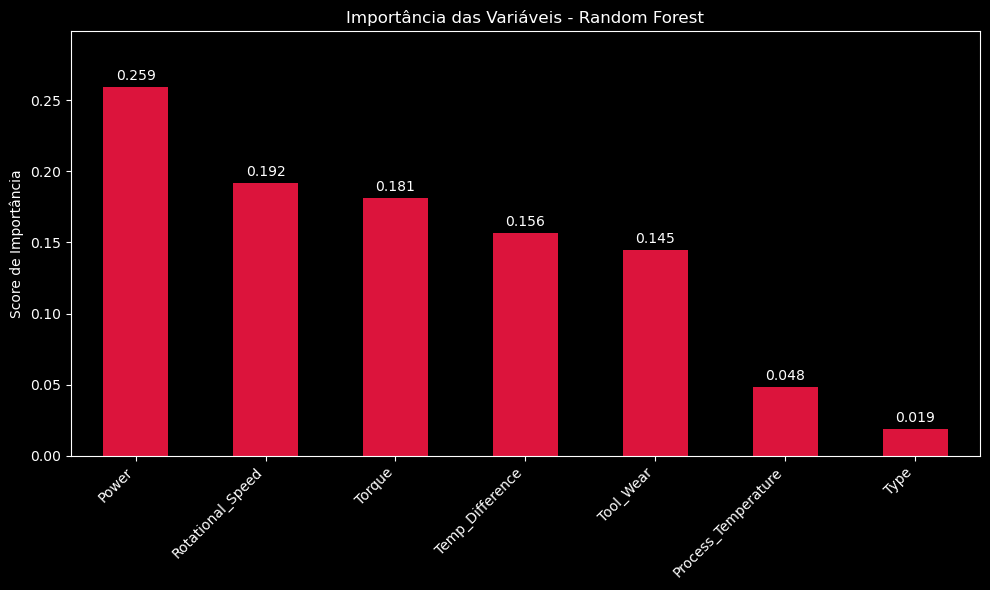

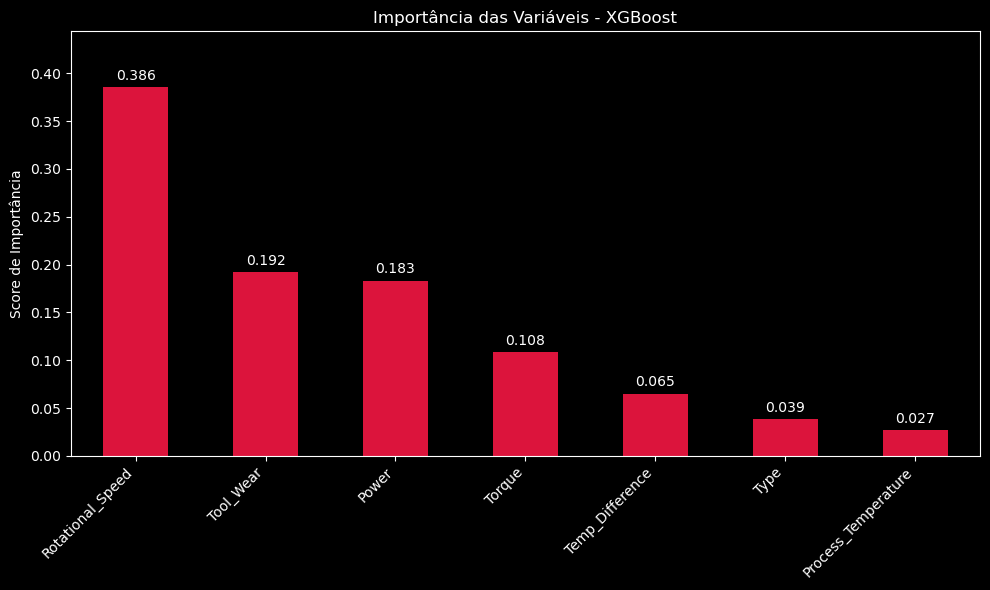

In [25]:
# Visualizar importancia das váriaveis
def plot_feature_importance(pipeline, model_name, X_train_columns):
    if model_name == 'Random Forest':
        model = pipeline.named_steps['classifier']
    else:
        model = pipeline.named_steps['xgb']
        
    # Extrai a importância
    importances = model.feature_importances_
    
    # Cria um DataFrame para facilitar a plotagem
    feature_imp = pd.Series(importances, index=X_train_columns).sort_values(ascending=False)
    
    # Plotagem
    plt.figure(figsize=(10, 6))
    ax = feature_imp.plot(kind='bar', color='crimson')
    plt.title(f'Importância das Variáveis - {model_name}')
    plt.ylabel('Score de Importância')
    plt.xticks(rotation=45, ha='right')
    ax.bar_label(ax.containers[0], fmt='%.3f', padding=3, fontsize=10)
    plt.ylim(0, feature_imp.max() * 1.15)
    plt.tight_layout()
    plt.show()

# Lista de colunas
cols = X_train_treated.columns 

# Plotar gráficos
plot_feature_importance(pipeline_rf, 'Random Forest', cols)
plot_feature_importance(pipeline_xgb, 'XGBoost', cols)

#### Feature Importance

O gráfico de importância do **Random Forest** valida perfeitamente as hipóteses físicas e as decisões de feature engineering aplicadas ao dataset:

* A variável criada Temp_Difference apresentou uma relevância quase 3 vezes maior (~0,137) do que a temperatura bruta Process_Temperature (~0,049). Isso confirma que a falha térmica está muito mais associada à deficiência na dissipação do calor do que à temperatura isolada da máquina.
* As variáveis mecânicas (Rotational_Speed, Torque e a criada Power) lideram a capacidade preditiva do modelo. A adição da variável Power (~0,18) provou ser um excelente atalho para o modelo identificar falhas de sobrecarga de potência, sem prejudicar a importância individual de velocidade e torque.
* A Tool_Wear consolidou-se como o segundo fator mais relevante do modelo (~0,205). As árvores de decisão conseguiram capturar com precisão o impacto do desgaste acumulado da ferramenta nas paradas do maquinário.


----

A análise do score de importância do **XGBoost** traz nuances importantes em relação ao Random Forest, evidenciando o impacto direto das variáveis criadas no algoritmo de Gradient Boosting:

* A variável Rotational_Speed domina de forma expressiva os cortes do modelo, atuando como o principal divisor de águas para identificar estados anômalos de operação (como rotação em vazio e sobrevelocidade).
* O XGBoost deu significativamente mais peso à variável criada Power do que ao Torque isolado (~0,108). A criação dessa feature atuou como um atalho direto para o algoritmo mapear situações de sobrecarga física e picos de demanda de energia sem necessidade de divisões profundas e repetitivas.
* A variável Temp_Difference (~0,065) manteve mais do dobro da importância em comparação à Process_Temperature (0,027). Isso revalida que a taxa de retenção/dissipação do calor é uma métrica mais ruidosa e preditiva do que o calor absoluto do processo isoladamente.
* A Tool_Wear consolida-se como a segunda variável mais relevante do projeto, garantindo que o acúmulo de uso do maquinário seja devidamente penalizado nas previsões de quebra por TWF (*Tool Wear Failure*).

## Otimização de modelos

In [26]:
# Definir a grade de parâmetros (Hyperparameter Grid)
# Obs: Os prefixos 'classifier__' e 'xgb__' referem-se ao nome do passo (step) dado no Pipeline

param_grid_rf = {
    'classifier__n_estimators': [100, 200, 300],                             # Quantidade de árvores na floresta
    'classifier__max_depth': [None, 10, 20],                                 # Profundidade máxima de cada árvore
    'classifier__min_samples_split': [2, 5, 10],                             # Mínimo de amostras necessárias para permitir a divisão de um nó
    'classifier__class_weight': ['balanced', 'balanced_subsample', None],    # Peso atribuído a cada classe
    'classifier__max_features': ['sqrt', 'log2']                             # Número de variáveis sorteadas aleatoriamente a cada quebra de nó
}

param_grid_xgb = {
    'xgb__n_estimators': [100, 200, 300],                                    # Número de iterações
    'xgb__learning_rate': [0.05, 0.1, 0.2],                                  # Taxa de aprendizado
    'xgb__max_depth': [3, 5, 7],                                             # Profundidade máxima de cada árvore
    'xgb__subsample': [0.8, 1.0],                                            # Fração de linhas (amostras) selecionadas aleatoriamente para treinar cada árvore
    'xgb__colsample_bytree': [0.8, 1.0]                                      # Fração de colunas (variáveis) selecionadas aleatoriamente para cada árvore
}

In [27]:
# Foco em F1-score

# GridSearchCV para Random Forest
grid_rf = GridSearchCV(
    pipeline_rf, 
    param_grid_rf, 
    cv=5, 
    scoring='f1',
    n_jobs=-1
)
grid_rf.fit(X_train_treated, y_train)
best_rf = grid_rf.best_estimator_

# Iniciando GridSearchCV para XGBoost
grid_xgb = GridSearchCV(
    pipeline_xgb, 
    param_grid_xgb, 
    cv=5, 
    scoring='f1', 
    n_jobs=-1
)
grid_xgb.fit(X_train_treated, y_train)
best_xgb = grid_xgb.best_estimator_

In [28]:
# Foco em Recall

# GridSearchCV para Random Forest
grid_rf_rec = GridSearchCV(
    pipeline_rf, 
    param_grid_rf, 
    cv=5, 
    scoring='recall', # Otimizando para o melhor F1-Score
    n_jobs=-1
)
grid_rf_rec.fit(X_train_treated, y_train)
best_rf_rec = grid_rf_rec.best_estimator_

# Iniciando GridSearchCV para XGBoost
grid_xgb_rec = GridSearchCV(
    pipeline_xgb, 
    param_grid_xgb, 
    cv=5, 
    scoring='recall',
    n_jobs=-1
)
grid_xgb_rec.fit(X_train_treated, y_train)
best_xgb_rec = grid_xgb_rec.best_estimator_

In [29]:
print("\nMelhores Parâmetros RF (f1):\n", grid_rf.best_params_)
print("\nMelhores Parâmetros XGB (f1):\n", grid_xgb.best_params_)
print("\n"+"-" * 100 + "\n")
print("\nMelhores Parâmetros RF (Recall):\n", grid_rf_rec.best_params_)
print("\nMelhores Parâmetros XGB (Recall):\n", grid_xgb_rec.best_params_)


Melhores Parâmetros RF (f1):
 {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Melhores Parâmetros XGB (f1):
 {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.2, 'xgb__max_depth': 7, 'xgb__n_estimators': 200, 'xgb__subsample': 0.8}

----------------------------------------------------------------------------------------------------


Melhores Parâmetros RF (Recall):
 {'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}

Melhores Parâmetros XGB (Recall):
 {'xgb__colsample_bytree': 1.0, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__n_estimators': 100, 'xgb__subsample': 0.8}


In [30]:
# Reavaliar com Cross-Validation usando os melhores modelos
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

modelos_otimizados = [
    ('Random Forest Otimizado F1', best_rf),
    ('XGBoost Otimizado F1', best_xgb),
    ('Random Forest Otimizado recall', best_rf_rec),
    ('XGBoost Otimizado recall', best_xgb_rec)
]

results_summary = []

print("\n--- Avaliação Detalhada (Cross-Validation com 5 Folds) ---")

for nome, pipe in modelos_otimizados:
    cv_results = cross_validate(pipe, X_train_treated, y_train, cv=5, scoring=scoring, n_jobs=-1)
    
    results_summary.append({
        'Modelo': nome,
        'Acurácia': np.mean(cv_results['test_accuracy']),
        'Precisão': np.mean(cv_results['test_precision']),
        'Recall': np.mean(cv_results['test_recall']),
        'F1-Score': np.mean(cv_results['test_f1']),
        'AUC-ROC': np.mean(cv_results['test_roc_auc'])
    })

df_results = pd.DataFrame(results_summary)
print(df_results.to_string(index=False))
print("-" * 50)


--- Avaliação Detalhada (Cross-Validation com 5 Folds) ---
                        Modelo  Acurácia  Precisão   Recall  F1-Score  AUC-ROC
    Random Forest Otimizado F1  0.989750  0.933890 0.752727  0.832760 0.981552
          XGBoost Otimizado F1  0.983875  0.739588 0.819057  0.776084 0.973004
Random Forest Otimizado recall  0.988375  0.867408 0.778586  0.819697 0.980265
      XGBoost Otimizado recall  0.934375  0.336873 0.951987  0.497010 0.979415
--------------------------------------------------


Análise e Insights: Matriz Comparativa de Otimização com GridSearchCV (F1-Score vs. Recall vs *Default*)

A matriz de experimentos com o GridSearchCV otimizando iterativamente para **F1-Score** (equilíbrio) e **Recall** (sensibilidade) trouxe clareza absoluta para a tomada de decisão estratégica:

* XGBoost Otimizado para F1 (Vencedor de Eficiência Geral):
  * Consolida-se como o **melhor modelo do projeto** até o momento, alcançando o maior F1-Score (0,776) e a maior Precisão (73,9%), mantendo um alto nível de Recall (81,9%). 
  * Essa calibração resolveu o problema de excesso de falsos alarmes do XGBoost padrão, tornando-o o pipeline mais econômico para a rotina diária da fábrica.

* Random Forest Otimizado para F1 (Alternativa Sólida e Estável):
  * Superou a versão *default* em todas as frentes (F1 de 0,735 e Precisão de 67,0%), reafirmando a robustez do algoritmo em evitar *overfitting*.

* XGBoost Otimizado para Recall (Sistemas de Alerta Precoce / EWS):
  * Entrega o teto máximo de detecção do projeto (Recall de 95,2%). É a configuração ideal para operação sob a filosofia de *zero-downtime*, onde perder uma única falha resulta em custos catastróficos que superam o custo de inspecionar alarmes falsos (Precisão de 33,7%).

* Random Forest Otimizado para Recall (Aumento de Sensibilidade com Degradação Moderada):
  * Ao direcionar a busca para a captura de falhas, o Random Forest subiu sua sensibilidade para 85,6% de Recall (contra 81,2% do padrão). 
  * Contudo, esse ganho de sensibilidade provocou uma queda na Precisão para 52,9% (F1 de 0,654). Embora seja mais conservador que a versão F1, ele se mostra menos extremo que o XGBoost Recall no volume de falsos alarmes.

---

Síntese para Decisão de Negócio

1. Modelo Principal de Operação (XGBoost Otimizado F1):
   * Deve ser implantado como o classificador padrão no pipeline de monitoramento preditivo para emitir ordens de manutenção com alta confiabilidade (74% de precisão) e baixíssima taxa de falsos alarmes.

2. Modelo Secundário de Segurança (XGBoost Otimizado Recall):
   * Pode atuar em paralelo como um **Early Warning System (EWS)** em maquinários de altíssima criticidade, disparando alertas de atenção para a equipe de engenharia quando a tolerância ao risco de quebra for zero.

In [31]:
# Teste Final na Base de Teste (Unseen Data) utilizando modelos focados em F1
# Nota: O best_estimator_ já vem treinado na base completa de treino pelo GridSearchCV (refit=True)

# Random Forest - F1
y_pred_rf_f1 = best_rf.predict(X_test_treated)

print("\n--- Teste Final: Random Forest Otimizado para F1 ---")
print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred_rf_f1))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_rf_f1))

# XGBoost - F1
y_pred_xgb_f1 = best_xgb.predict(X_test_treated)

print("\n--- Teste Final: XGBoost Otimizado para F1---")
print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred_xgb_f1))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_xgb_f1))


--- Teste Final: Random Forest Otimizado para F1 ---
Matriz de confusão:
[[1928    4]
 [  17   51]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.93      0.75      0.83        68

    accuracy                           0.99      2000
   macro avg       0.96      0.87      0.91      2000
weighted avg       0.99      0.99      0.99      2000


--- Teste Final: XGBoost Otimizado para F1---
Matriz de confusão:
[[1908   24]
 [  12   56]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.70      0.82      0.76        68

    accuracy                           0.98      2000
   macro avg       0.85      0.91      0.87      2000
weighted avg       0.98      0.98      0.98      2000



In [32]:
# Teste Final na Base de Teste (Unseen Data) utilizando modelos focados em Recall
# Nota: O best_estimator_ já vem treinado na base completa de treino pelo GridSearchCV (refit=True)

# Random Forest - Recall
y_pred_rf_rec = best_rf_rec.predict(X_test_treated)

print("\n--- Teste Final: Random Forest Otimizado para Recall---")
print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred_rf_rec))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_rf_rec))

# XGBoost - Recall
y_pred_xgb_rec = best_xgb_rec.predict(X_test_treated)

print("\n--- Teste Final: XGBoost Otimizado para Recall---")
print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred_xgb_rec))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_xgb_rec))


--- Teste Final: Random Forest Otimizado para Recall---
Matriz de confusão:
[[1921   11]
 [  17   51]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.82      0.75      0.78        68

    accuracy                           0.99      2000
   macro avg       0.91      0.87      0.89      2000
weighted avg       0.99      0.99      0.99      2000


--- Teste Final: XGBoost Otimizado para Recall---
Matriz de confusão:
[[1789  143]
 [   4   64]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1932
           1       0.31      0.94      0.47        68

    accuracy                           0.93      2000
   macro avg       0.65      0.93      0.71      2000
weighted avg       0.97      0.93      0.94      2000



Análise e Insights: Teste Final e Comparativo dos Modelos

A avaliação no conjunto de teste (2.000 amostras inéditas) ratifica o sucesso da otimização via GridSearchCV e define com clareza o papel de cada pipeline na estratégia de manutenção:

* **XGBoost Otimizado para F1 (O Campeão de Eficiência Operacional):**
  * Melhor Resultado Geral, ao alcançar o maior F1-Score (0,76) do projeto, impulsionado por 70% de Precisão e 82% de Recall.
  * Redução Drástica de Custos em comparação ao XGBoost *default* (que gerava 60 falsos alarmes), a otimização focada em F1 reduziu os Falsos Positivos para apenas 24, eliminando 60% das inspeções desnecessárias na rotina da fábrica sem comprometer a detecção de quebras (56 falhas capturadas de 68).

* **XGBoost Otimizado para Recall (A Máxima Cobertura de Falhas / EWS):**
  * Entregou a maior taxa de detecção do projeto (94% de Recall), capturando **64 de 68 falhas reais** e deixando passar apenas 4 falhas (Falsos Negativos).
  * Devido à sua postura ultra-conservadora, apresentou baixa Precisão (31%) ao gerar 143 Falsos Positivos, sendo o modelo indicado estritamente para cenários onde a falha é intolerável.

* **Random Forest Otimizado (Estabilidade e Meio-Termo):**
  * A versão otimizada para F1 sustentou o equilíbrio histórico (F1 de 0,69, Recall de 82% e Precisão de 59%).
  * Ao ser otimizado para Recall, o RF elevou a detecção para 87% (59 falhas capturadas), com uma Precisão de 49% (61 FPs), posicionando-se como uma alternativa conservadora menos drástica que o XGBoost Recall.

---

Recomendação de Decisão de Negócio

1. **Modelo Primário Padrão (XGBoost Otimizado F1):**
   * Aplicação: Rotina operacional diária de manutenção preditiva.
   * Justificativa: Entrega a melhor combinação entre confiabilidade dos alertas (70% de precisão) e alta taxa de detecção (82%), minimizando simultaneamente os custos de paradas e o deslocamento indevido de técnicos.

2. **Modelo Secundário de Segurança (XGBoost Otimizado Recall):**
   * Aplicação: Maquinários críticos sob filosofia *zero-downtime* (Early Warning System).
   * Justificativa: Proporciona quase 100% de garantia de detecção (94% de captura) para linhas de produção onde o custo de uma quebra supere drasticamente o custo operacional de checar alarmes falsos.